In [2]:
import pandas as pd
import os
import numpy as np

In [3]:
# 주피터 노트북에서 표가 좌우로 잘리지 않게 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# w1 기상청 ASOS(지상관측) 실제 관측 날씨 데이터 (raw_w1_asos.csv)

In [4]:
w1_path = '../data/01_raw/raw_w1_asos.csv'

In [44]:
os.path.exists(w1_path)

# 1. 헤더 없이 깔끔하게 파일 불러오기
w1 = pd.read_csv(w1_path, header=None)
    
# 2. 기상청 일자료 표준 컬럼 이름 정의
w1_columns = [
    'TM', 'STN', 'WS_AVG', 'WR_DAY', 'WD_MAX', 'WS_MAX', 'WS_MAX_TM', 
    'WD_INS', 'WS_INS', 'WS_INS_TM', 'TA_AVG', 'TA_MAX', 'TA_MAX_TM', 
    'TA_MIN', 'TA_MIN_TM', 'TD_AVG', 'TS_AVG', 'TG_MIN', 'HM_AVG', 
    'HM_MIN', 'HM_MIN_TM', 'PV_AVG', 'EV_S', 'EV_L', 'FG_DUR', 'PA_AVG', 
    'PS_AVG', 'PS_MAX', 'PS_MAX_TM', 'PS_MIN', 'PS_MIN_TM', 'CA_TOT', 
    'SS_DAY', 'SS_DUR', 'SS_CMB', 'SI_DAY', 'SI_60M_MAX', 'SI_60M_MAX_TM', 
    'RN_DAY', 'RN_D99', 'RN_DUR', 'RN_60M_MAX', 'RN_60M_MAX_TM', 
    'RN_10M_MAX', 'RN_10M_MAX_TM', 'RN_POW_MAX', 'RN_POW_MAX_TM', 
    'SD_NEW', 'SD_NEW_TM', 'SD_MAX', 'SD_MAX_TM', 'TE_05', 'TE_10', 'TE_15', 'TE_30', 'TE_50'
]
# 3. 데이터프레임 실제 열 개수에 맞춰 컬럼 이름 맵핑하기
w1.columns = w1_columns[:len(w1.columns)]
    
print(f"총 데이터 크기: {w1.shape}")
display(w1.head(3))


총 데이터 크기: (1309, 56)


,TM,STN,WS_AVG,WR_DAY,WD_MAX,WS_MAX,WS_MAX_TM,WD_INS,WS_INS,WS_INS_TM,TA_AVG,TA_MAX,TA_MAX_TM,TA_MIN,TA_MIN_TM,TD_AVG,TS_AVG,TG_MIN,HM_AVG,HM_MIN,HM_MIN_TM,PV_AVG,EV_S,EV_L,FG_DUR,PA_AVG,PS_AVG,PS_MAX,PS_MAX_TM,PS_MIN,PS_MIN_TM,CA_TOT,SS_DAY,SS_DUR,SS_CMB,SI_DAY,SI_60M_MAX,SI_60M_MAX_TM,RN_DAY,RN_D99,RN_DUR,RN_60M_MAX,RN_60M_MAX_TM,RN_10M_MAX,RN_10M_MAX_TM,RN_POW_MAX,RN_POW_MAX_TM,SD_NEW,SD_NEW_TM,SD_MAX,SD_MAX_TM,TE_05,TE_10,TE_15,TE_30,TE_50
0,0,1,2.00,3,4,5.00,6,7,8.00,9,10.00,11.00,12,13.00,14,15.00,16.00,17.00,18.00,19.00,20,21.00,22.00,23.00,24.00,25.00,26.00,27.00,28,29.00,30,31.00,32.00,33.00,34.00,35.00,36.00,37,38.00,39.00,40.00,41.00,42,43.00,44,45.00,46,47.00,48,49.00,50,51.00,52.00,53.00,54.00,55.00
1,20230101,108,2.70,2314,32,5.30,2135,29,8.10,1406,-0.20,3.80,1343,-4.30,2350,-8.70,-1.40,-8.10,54.50,28.00,1656,3.30,2.30,1.60,-9.00,1019.80,1030.80,1033.20,2253,1028.60,137,1.30,9.00,9.60,-9.00,10.81,1.87,1200,-9.00,-9.00,-9.00,-9.00,-9,-9.00,-9,-9.00,-9,-9.00,-9,-9.00,-9,2.80,6.30,10.10,15.90,18.00
2,20230102,108,2.50,2176,29,4.40,1307,25,7.40,1501,-4.50,-0.40,1525,-7.40,804,-14.60,-4.20,-13.40,45.90,32.00,1543,2.00,1.90,1.30,-9.00,1021.00,1032.20,1034.00,1005,1030.30,1521,0.00,9.10,9.60,-9.00,11.63,1.99,1200,-9.00,-9.00,-9.00,-9.00,-9,-9.00,-9,-9.00,-9,-9.00,-9,-9.00,-9,2.70,6.20,9.90,15.80,17.90


In [6]:
pd.options.display.float_format = '{:.2f}'.format

In [45]:
display(w1.describe())

,TM,STN,WS_AVG,WR_DAY,WD_MAX,WS_MAX,WS_MAX_TM,WD_INS,WS_INS,WS_INS_TM,TA_AVG,TA_MAX,TA_MAX_TM,TA_MIN,TA_MIN_TM,TD_AVG,TS_AVG,TG_MIN,HM_AVG,HM_MIN,HM_MIN_TM,PV_AVG,EV_S,EV_L,FG_DUR,PA_AVG,PS_AVG,PS_MAX,PS_MAX_TM,PS_MIN,PS_MIN_TM,CA_TOT,SS_DAY,SS_DUR,SS_CMB,SI_DAY,SI_60M_MAX,SI_60M_MAX_TM,RN_DAY,RN_D99,RN_DUR,RN_60M_MAX,RN_60M_MAX_TM,RN_10M_MAX,RN_10M_MAX_TM,RN_POW_MAX,RN_POW_MAX_TM,SD_NEW,SD_NEW_TM,SD_MAX,SD_MAX_TM,TE_05,TE_10,TE_15,TE_30,TE_50
count,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00
mean,20228403.79,107.92,2.26,1985.41,21.16,4.66,1389.18,21.04,8.33,1370.14,14.21,18.92,1380.57,10.18,923.47,7.10,15.34,5.57,64.93,45.01,1359.46,13.12,4.03,2.82,-8.85,1004.61,1014.83,1014.26,1125.00,1009.25,1273.55,4.76,6.19,12.29,-8.97,14.65,2.27,1201.90,-1.20,-1.20,-2.46,-4.98,172.94,-5.80,201.25,-8.96,-8.96,-8.51,42.43,-8.18,42.39,15.24,15.27,16.06,16.29,16.32
std,559627.70,2.96,0.94,561.28,9.30,1.42,524.86,9.42,2.70,529.98,10.74,10.74,383.58,11.02,725.84,11.86,11.60,12.38,14.35,16.81,440.46,9.14,2.61,1.95,1.53,28.22,28.58,63.50,923.16,63.16,746.71,3.20,4.23,1.98,1.19,7.76,1.48,149.17,15.05,15.51,8.67,7.98,623.76,5.65,562.93,1.49,1.52,2.84,299.78,3.59,299.45,9.30,7.87,6.80,4.02,6.05
min,0.00,1.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-14.70,-8.20,1.00,-17.30,1.00,-22.50,-7.20,-19.40,18.00,10.00,1.00,1.00,-9.00,-9.00,-9.00,25.00,26.00,-9.00,-9.00,-9.00,-9.00,0.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-2356.00,-9.00,-2356.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,1.20,3.50,6.10,10.80,-99.00
25%,20231123.00,108.00,1.90,1599.00,18.00,3.80,1210.00,16.00,6.50,1205.00,4.70,9.40,1356.00,0.70,536.00,-2.20,3.90,-5.60,54.30,32.00,1318.00,5.30,2.00,1.40,-9.00,999.20,1009.10,1011.30,133.00,1006.80,455.00,2.00,2.30,10.60,-9.00,8.99,1.74,1200.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,6.00,7.40,9.40,12.60,14.60
50%,20241015.00,108.00,2.20,1889.00,25.00,4.50,1458.00,25.00,8.00,1449.00,15.50,20.90,1454.00,10.90,628.00,7.70,16.40,5.30,65.30,44.00,1437.00,10.60,3.50,2.50,-9.00,1005.00,1015.20,1018.00,910.00,1012.60,1541.00,4.80,6.80,12.40,-9.00,13.84,2.32,1200.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,15.80,15.40,15.90,15.60,16.30
75%,20250907.00,108.00,2.60,2265.00,29.00,5.30,1719.00,29.00,9.70,1701.00,23.70,27.90,1538.00,20.00,800.00,17.40,25.70,16.70,75.30,56.00,1555.00,20.00,5.80,4.10,-9.00,1011.60,1022.10,1025.00,2256.00,1019.70,1724.00,7.40,9.50,14.10,-9.00,20.26,3.04,1300.00,0.60,0.50,2.92,0.00,-9.00,0.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,24.20,22.70,22.40,20.20,18.40
max,20260731.00,108.00,6.30,5412.00,36.00,9.30,2357.00,36.00,21.50,2400.00,32.80,38.00,2359.00,29.30,2400.00,25.70,38.80,26.70,99.10,96.00,2357.00,33.10,22.00,23.00,24.00,1025.50,1036.70,1039.00,2400.00,1034.50,2400.00,31.00,32.00,33.00,34.00,35.00,36.00,1700.00,128.80,152.30,40.00,63.30,2331.00,43.00,2356.00,45.00,46.00,47.00,2359.00,49.00,2359.00,51.00,52.00,53.00,54.00,55.00


In [46]:
display(w1[key_cols].describe())

,TM,TA_AVG,TA_MAX,TA_MIN,HM_AVG,RN_DAY
count,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00
mean,20228403.79,14.21,18.92,10.18,64.93,-1.20
std,559627.70,10.74,10.74,11.02,14.35,15.05
min,0.00,-14.70,-8.20,-17.30,18.00,-9.00
25%,20231123.00,4.70,9.40,0.70,54.30,-9.00
50%,20241015.00,15.50,20.90,10.90,65.30,-9.00
75%,20250907.00,23.70,27.90,20.00,75.30,0.60
max,20260731.00,32.80,38.00,29.30,99.10,128.80


In [47]:
invalid_counts = (w1 == -99).sum()
cols_to_preprocess = invalid_counts[invalid_counts > 0]
print("전처리가 필요한 컬럼과 결측치 개수:")
display(cols_to_preprocess)

전처리가 필요한 컬럼과 결측치 개수:


TE_50    3
dtype: int64

In [48]:
# 강수량(RN_DAY) 컬럼에 -9가 들어있는지 확인
invalid_rn = (w1['RN_DAY'] == -9).sum()
print(f"강수량 컬럼에서 -9가 기록된 횟수: {invalid_rn}건")

강수량 컬럼에서 -9가 기록된 횟수: 754건


In [50]:
# 1. 강수량(RN_DAY)의 -9는 음수가 불가능하므로 NaN으로 변환
w1.loc[w1['RN_DAY'] == -9, 'RN_DAY'] = np.nan

# 2. TE_50의 -99는 NaN으로 변환
w1.loc[w1['TE_50'] == -99, 'TE_50'] = np.nan

print("결측치(이상값) 전처리 완료!")
print(f"변환 후 강수량 결측치 개수: {w1['RN_DAY'].isna().sum()}건")
print(f"변환 후 TE_50 결측치 개수: {w1['TE_50'].isna().sum()}건")

결측치(이상값) 전처리 완료!
변환 후 강수량 결측치 개수: 754건
변환 후 TE_50 결측치 개수: 3건


In [51]:
# 1. 날짜(TM) 컬럼을 문자열 또는 날짜형으로 변환하기 전, 이상한 값(0 등)이 있는지 확인
invalid_dates = w1[w1['TM'] <= 0]
print(f"⚠️ 이상한 날짜(0 이하) 개수: {len(invalid_dates)}건")

⚠️ 이상한 날짜(0 이하) 개수: 1건


In [52]:
# 1. 날짜가 0 이하를 가진 행이 대체 어떤 데이터인지 확인
invalid_row = w1[w1['TM'] <= 0]
display(invalid_row)

,TM,STN,WS_AVG,WR_DAY,WD_MAX,WS_MAX,WS_MAX_TM,WD_INS,WS_INS,WS_INS_TM,TA_AVG,TA_MAX,TA_MAX_TM,TA_MIN,TA_MIN_TM,TD_AVG,TS_AVG,TG_MIN,HM_AVG,HM_MIN,HM_MIN_TM,PV_AVG,EV_S,EV_L,FG_DUR,PA_AVG,PS_AVG,PS_MAX,PS_MAX_TM,PS_MIN,PS_MIN_TM,CA_TOT,SS_DAY,SS_DUR,SS_CMB,SI_DAY,SI_60M_MAX,SI_60M_MAX_TM,RN_DAY,RN_D99,RN_DUR,RN_60M_MAX,RN_60M_MAX_TM,RN_10M_MAX,RN_10M_MAX_TM,RN_POW_MAX,RN_POW_MAX_TM,SD_NEW,SD_NEW_TM,SD_MAX,SD_MAX_TM,TE_05,TE_10,TE_15,TE_30,TE_50
0,0,1,2.00,3,4,5.00,6,7,8.00,9,10.00,11.00,12,13.00,14,15.00,16.00,17.00,18.00,19.00,20,21.00,22.00,23.00,24.00,25.00,26.00,27.00,28,29.00,30,31.00,32.00,33.00,34.00,35.00,36.00,37,38.00,39.00,40.00,41.00,42,43.00,44,45.00,46,47.00,48,49.00,50,51.00,52.00,53.00,54.00,55.00


In [53]:
# 2. 해당 이상한 행을 깔끔하게 제거하기
w1 = w1[w1['TM'] > 0].reset_index(drop=True)

In [54]:
# 2. 날짜 중복 확인
duplicates = w1['TM'].duplicated().sum()
print(f"중복된 날짜 개수: {duplicates}건")

중복된 날짜 개수: 0건


In [55]:
# 3. 날짜 형식을 판다스 datetime으로 변환 후 연속성(누락일) 확인
# (TM이 '20230101' 형태의 정수/문자열이라고 가정)
w1['Date'] = pd.to_datetime(w1['TM'].astype(str), format='%Y%m%d', errors='coerce')
w1 = w1.sort_values('Date').reset_index(drop=True)

# 전체 기간 동안 하루씩 비는 날이 있는지 확인
expected_days = (w1['Date'].max() - w1['Date'].min()).days + 1
actual_days = w1['Date'].nunique()
print(f"전체 날짜 범위: {w1['Date'].min().date()} ~ {w1['Date'].max().date()}")
print(f"총 일수 (기대값): {expected_days}일 / 실제 데이터 수: {actual_days}일")

if expected_days == actual_days:
    print("날짜 누락 없이 완벽하게 연속된 3년 치 시계열 데이터입니다!")
else:
    print(f"중간에 누락된 날짜가 총 {expected_days - actual_days}일 있습니다.")

전체 날짜 범위: 2023-01-01 ~ 2026-07-31
총 일수 (기대값): 1308일 / 실제 데이터 수: 1308일
날짜 누락 없이 완벽하게 연속된 3년 치 시계열 데이터입니다!


In [65]:
# 4. 분석에 쓸 핵심 컬럼(날짜, 평균기온, 최고기온, 최저기온, 습도, 강수량)만 보기
key_cols = ['TM', 'TA_AVG', 'TA_MAX', 'TA_MIN', 'HM_AVG', 'RN_DAY']
display(w1[key_cols].head(3))

,TM,TA_AVG,TA_MAX,TA_MIN,HM_AVG,RN_DAY
0,20230101,-0.20,3.80,-4.30,54.50,NaN
1,20230102,-4.50,-0.40,-7.40,45.90,NaN
2,20230103,-5.00,0.60,-9.00,49.00,NaN


In [66]:
display(w1[key_cols].describe())

,TM,TA_AVG,TA_MAX,TA_MIN,HM_AVG,RN_DAY
count,1308.00,1308.00,1308.00,1308.00,1308.00,554.00
mean,20243868.93,14.21,18.93,10.17,64.96,9.34
std,10438.98,10.75,10.74,11.03,14.30,18.41
min,20230101.00,-14.70,-8.20,-17.30,22.90,0.00
25%,20231123.75,4.70,9.38,0.70,54.30,0.00
50%,20241015.50,15.50,20.90,10.90,65.30,1.30
75%,20250907.25,23.73,27.90,20.00,75.30,9.43
max,20260731.00,32.80,38.00,29.30,99.10,128.80


In [68]:
print(w1[key_cols].dtypes)

TM          int64
TA_AVG    float64
TA_MAX    float64
TA_MIN    float64
HM_AVG    float64
RN_DAY    float64
dtype: object


In [71]:
# int64 숫자를 문자열로 바꾼 뒤 datetime 형식으로 변환
# (기상청 일자료가 '20230101' 형태의 정수일 때)
w1['TM'] = pd.to_datetime(
    w1['TM'].astype(str), format='%Y%m%d'
)

In [73]:
# 타입이 잘 바뀌었는지 다시 확인
print(w1['TM'].dtype)  # 출력 결과가 datetime64[ns]로 나와야 성공!
print(w1['TM'].head())

datetime64[ns]
0   2023-01-01
1   2023-01-02
2   2023-01-03
3   2023-01-04
4   2023-01-05
Name: TM, dtype: datetime64[ns]


월별 평균기온, 최고기온, 최저기온, 습도, 강수량

In [75]:
# 1. 월(Month) 컬럼 추출
w1['month'] = w1['TM'].dt.month

In [78]:
# 2. 계절(Season) 컬럼 생성 함수 정의
def get_season(month):
  if month in [3, 4, 5]:
    return 'Spring (봄)'
  elif month in [6, 7, 8]:
    return 'Summer (여름)'
  elif month in [9, 10, 11]:
    return 'Fall (가을)'
  else:
    return 'Winter (겨울)'
  
w1['season'] = w1['month'].apply(get_season)

In [79]:
# 3. [월별] 핵심 컬럼 평균 요약
monthly_summary = w1.groupby('month')[[
    'TA_AVG',
    'TA_MAX',
    'TA_MIN',
    'HM_AVG',
    'RN_DAY',
]].mean()
print('================ [월별 기상 패턴 요약] ================')
print(monthly_summary)

================ [월별 기상 패턴 요약] ================
       TA_AVG  TA_MAX  TA_MIN  HM_AVG  RN_DAY
month                                        
1       -1.51    2.91   -5.38   60.79    1.84
2        1.93    6.84   -2.21   60.60    2.80
3        8.23   13.94    3.35   54.90    3.22
4       14.64   20.40    9.48   56.95    6.21
5       18.85   24.18   14.08   63.14   10.55
6       24.02   28.97   19.77   65.44    9.01
7       27.25   30.62   24.51   78.11   20.20
8       28.25   32.01   25.30   74.84   12.48
9       24.20   28.28   20.83   73.55   15.10
10      16.31   20.93   12.41   70.54    7.67
11       8.48   13.55    4.33   62.72    5.08
12       1.07    5.26   -2.75   62.32    3.41


In [80]:
# 5. [계절별] 핵심 컬럼 평균 및 일교차 파생변수 생성 후 요약
w1['TA_DIFF'] = w1['TA_MAX'] - w1['TA_MIN']  # 일교차 파생변수

seasonal_summary = w1.groupby('season').agg({
    'TA_AVG': 'mean',
    'TA_MAX': 'mean',
    'TA_MIN': 'mean',
    'TA_DIFF': 'mean',  # 평균 일교차
    'HM_AVG': 'mean',
    'RN_DAY': 'sum',  # 계절별 총 강수량 합계
})
print('\n================ [계절별 기상 패턴 요약] ================')
print(seasonal_summary)


================ [계절별 기상 패턴 요약] ================
             TA_AVG  TA_MAX  TA_MIN  TA_DIFF  HM_AVG  RN_DAY
season                                                      
Fall (가을)     16.33   20.92   12.52     8.40   68.95 1103.10
Spring (봄)    13.90   19.50    8.96    10.54   58.34  904.70
Summer (여름)   26.38   30.42   23.04     7.38   72.69 2853.70
Winter (겨울)    0.39    4.92   -3.55     8.47   61.15  310.80


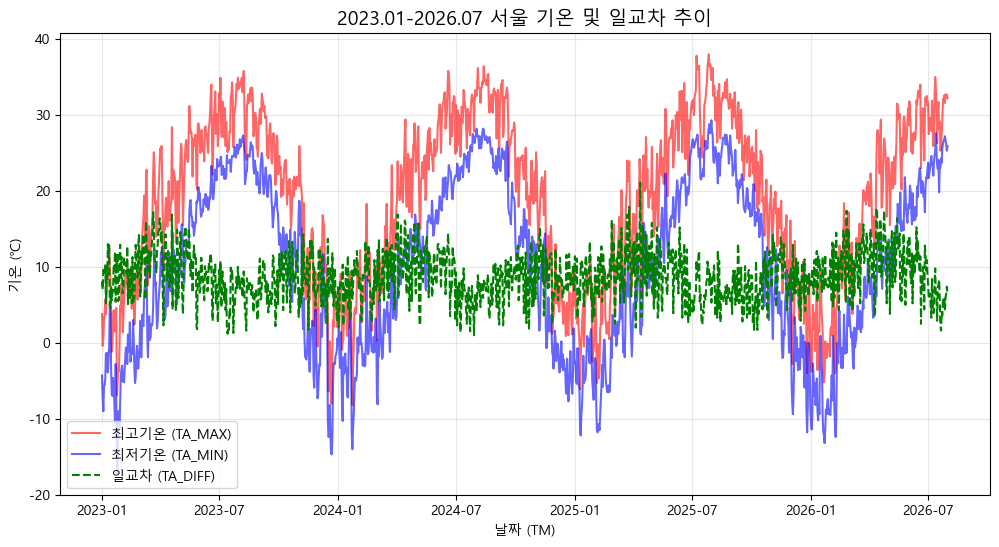

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 깨짐 방지 (시스템 환경에 맞춰 설정)
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows의 경우
plt.rcParams['axes.unicode_minus'] = False

# 1. 시계열 기온 및 일교차 추이 선 그래프
plt.figure(figsize=(12, 6))
plt.plot(
    w1['TM'],
    w1['TA_MAX'],
    label='최고기온 (TA_MAX)',
    color='red',
    alpha=0.6,
)
plt.plot(
    w1['TM'],
    w1['TA_MIN'],
    label='최저기온 (TA_MIN)',
    color='blue',
    alpha=0.6,
)
plt.plot(
    w1['TM'],
    w1['TA_DIFF'],
    label='일교차 (TA_DIFF)',
    color='green',
    linestyle='--',
)

plt.title('2023.01-2026.07 서울 기온 및 일교차 추이', fontsize=14)
plt.xlabel('날짜 (TM)')
plt.ylabel('기온 (℃)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# w2 ~ w3 기상청 일기예보 및 특보 데이터 (kma_forest_all.csv) 

In [18]:
# 통합된 기상예보 데이터 로드
df_forecast = pd.read_csv("../data/raw/kma_forecast/kma_forecast_all.csv")

# 기본 정보 및 상단 5행 확인
print(f"전체 데이터 행 수: {len(df_forecast):,}, 컬럼 수: {df_forecast.shape[1]}")
display(df_forecast.head())
display(df_forecast.info())

전체 데이터 행 수: 49,440, 컬럼 수: 31


,src,region,reg_id,tmfc,tm_ef,target_date,mod,t_max,t_min,rn_st,sky,wf,sky_name,pre_name,REG_ID,TM_FC,TM_EF,MOD,STN,C,MIN,MAX,MIN_L,MIN_H,MAX_L,MAX_H,SKY,PRE,CONF,WF,RN_ST
0,land,서울,11B00000,2023-01-01 06:00:00,2023-01-04 00:00:00,2023-01-04,A02,NaN,NaN,0.00,WB01,맑음,맑음,없음,11B00000,202301010600,202301040000,A02,109,2,NaN,NaN,NaN,NaN,NaN,NaN,WB01,WB00,없음,맑음,0.00
1,land,서울,11B00000,2023-01-01 06:00:00,2023-01-04 12:00:00,2023-01-04,A02,NaN,NaN,0.00,WB01,맑음,맑음,없음,11B00000,202301010600,202301041200,A02,109,2,NaN,NaN,NaN,NaN,NaN,NaN,WB01,WB00,없음,맑음,0.00
2,land,서울,11B00000,2023-01-01 06:00:00,2023-01-05 00:00:00,2023-01-05,A02,NaN,NaN,10.00,WB01,맑음,맑음,없음,11B00000,202301010600,202301050000,A02,109,2,NaN,NaN,NaN,NaN,NaN,NaN,WB01,WB00,없음,맑음,10.00
3,land,서울,11B00000,2023-01-01 06:00:00,2023-01-05 12:00:00,2023-01-05,A02,NaN,NaN,0.00,WB01,맑음,맑음,없음,11B00000,202301010600,202301051200,A02,109,2,NaN,NaN,NaN,NaN,NaN,NaN,WB01,WB00,없음,맑음,0.00
4,land,서울,11B00000,2023-01-01 06:00:00,2023-01-06 00:00:00,2023-01-06,A02,NaN,NaN,20.00,WB03,구름많음,구름많음,없음,11B00000,202301010600,202301060000,A02,109,2,NaN,NaN,NaN,NaN,NaN,NaN,WB03,WB00,없음,구름많음,20.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49440 entries, 0 to 49439
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   src          49440 non-null  object 
 1   region       49440 non-null  object 
 2   reg_id       49440 non-null  object 
 3   tmfc         49440 non-null  object 
 4   tm_ef        49440 non-null  object 
 5   target_date  49440 non-null  object 
 6   mod          49440 non-null  object 
 7   t_max        19095 non-null  float64
 8   t_min        19095 non-null  float64
 9   rn_st        30344 non-null  float64
 10  sky          30344 non-null  object 
 11  wf           30344 non-null  object 
 12  sky_name     30344 non-null  object 
 13  pre_name     30344 non-null  object 
 14  REG_ID       49440 non-null  object 
 15  TM_FC        49440 non-null  int64  
 16  TM_EF        49440 non-null  int64  
 17  MOD          49440 non-null  object 
 18  STN          49440 non-null  int64  
 19  C   

None

In [19]:
# 1. 수치형 데이터 기초통계 (최고/최저기온, 강수확률 등)
print("--- [수치형 데이터 기초통계] ---")
display(df_forecast[['t_max', 't_min', 'rn_st']].describe())

# 2. 범주형 데이터 분포 확인 (src, sky_name, pre_name 등)
print("\n--- [범주형 데이터 분포] ---")
for col in ['src', 'sky_name', 'pre_name']:
    if col in df_forecast.columns:
        print(f"\n[{col} 카운트]")
        print(df_forecast[col].value_counts(dropna=False).head(5))

# 3. 결측치 확인
print("\n--- [컬럼별 결측치 개수] ---")
missing_df = df_forecast.isnull().sum()
print(missing_df[missing_df > 0])

--- [수치형 데이터 기초통계] ---


,t_max,t_min,rn_st
count,19095.00,19095.00,30344.00
mean,18.62,10.59,27.79
std,10.68,10.57,20.23
min,-12.00,-17.00,0.00
25%,9.00,1.00,10.00
50%,21.00,11.00,20.00
75%,28.00,20.00,40.00
max,37.00,27.00,100.00



--- [범주형 데이터 분포] ---

[src 카운트]
src
land    30344
temp    19096
Name: count, dtype: int64

[sky_name 카운트]
sky_name
NaN     19096
맑음      12183
구름많음    10502
흐림       7659
Name: count, dtype: int64

[pre_name 카운트]
pre_name
없음     27259
NaN    19096
비       2781
비/눈      245
눈         59
Name: count, dtype: int64

--- [컬럼별 결측치 개수] ---
t_max       30345
t_min       30345
rn_st       19096
sky         19096
wf          19096
sky_name    19096
pre_name    19096
MIN         30345
MAX         30345
MIN_L       30344
MIN_H       30344
MAX_L       30344
MAX_H       30344
SKY         19096
PRE         19096
CONF        19096
WF          19096
RN_ST       19096
dtype: int64


In [20]:
# 1. 시계열 관련 컬럼들을 datetime 형식으로 변환
datetime_cols = ['tmfc', 'target_date', 'tm_ef']

for col in datetime_cols:
    if col in df_forecast.columns:
        df_forecast[col] = pd.to_datetime(df_forecast[col], errors='coerce')

# 2. 변환 후 데이터 타입(dtypes) 확인
print("--- [시계열 컬럼 타입 확인] ---")
print(df_forecast[[col for col in datetime_cols if col in df_forecast.columns]].dtypes)

# 3. 날짜 범위가 올바르게 들어갔는지 최소/최대값 확인
if 'target_date' in df_forecast.columns:
    print(f"\n예보 대상일 범위: {df_forecast['target_date'].min()} ~ {df_forecast['target_date'].max()}")

--- [시계열 컬럼 타입 확인] ---
tmfc           datetime64[ns]
target_date    datetime64[ns]
tm_ef          datetime64[ns]
dtype: object

예보 대상일 범위: 2023-01-04 00:00:00 ~ 2026-08-10 00:00:00


In [21]:
print("--- [1. 예보 데이터(df_forecast) 결측치 점검] ---")
forecast_na = df_forecast[['t_max', 't_min', 'rn_st', 'sky_name']].isnull().sum()
print(forecast_na)

--- [1. 예보 데이터(df_forecast) 결측치 점검] ---
t_max       30345
t_min       30345
rn_st       19096
sky_name    19096
dtype: int64


In [22]:
# 1. src를 기준으로 기온 데이터(temp)와 육상 데이터(land) 분리하기
df_temp = df_forecast[df_forecast['src'] == 'temp'].copy()
df_land = df_forecast[df_forecast['src'] == 'land'].copy()

In [23]:
# 2. 불필요하거나 중복되는 src 컬럼은 미리 제거
df_temp = df_temp.drop(columns=['src'], errors='ignore')
df_land = df_land.drop(columns=['src'], errors='ignore')

In [24]:
# 3. tmfc와 target_date를 공통 키(Key)로 삼아 가로(좌우)로 병합(Merge)하기
# 두 데이터가 날짜별로 정확히 짝을 이룰 수 있도록 outer 또는 inner 조인 선택
df_forecast_merged = pd.merge(
    df_temp, 
    df_land, 
    on=['tmfc', 'target_date', 'region'], 
    how='inner', 
    suffixes=('_temp', '_land')
)

In [25]:
# 4. 결과 확인
print(f"병합 전 행 수 - 기온: {len(df_temp):,}, 육상: {len(df_land):,}")
print(f"병합 후 최종 단일 테이블 행 수: {len(df_forecast_merged):,}, 컬럼 수: {df_forecast_merged.shape[1]}개")
display(df_forecast_merged.head(3))

병합 전 행 수 - 기온: 19,096, 육상: 30,344
병합 후 최종 단일 테이블 행 수: 30,344, 컬럼 수: 57개


,region,reg_id_temp,tmfc,tm_ef_temp,target_date,mod_temp,t_max_temp,t_min_temp,rn_st_temp,sky_temp,wf_temp,sky_name_temp,pre_name_temp,REG_ID_temp,TM_FC_temp,TM_EF_temp,MOD_temp,STN_temp,C_temp,MIN_temp,MAX_temp,MIN_L_temp,MIN_H_temp,MAX_L_temp,MAX_H_temp,SKY_temp,PRE_temp,CONF_temp,WF_temp,RN_ST_temp,reg_id_land,tm_ef_land,mod_land,t_max_land,t_min_land,rn_st_land,sky_land,wf_land,sky_name_land,pre_name_land,REG_ID_land,TM_FC_land,TM_EF_land,MOD_land,STN_land,C_land,MIN_land,MAX_land,MIN_L_land,MIN_H_land,MAX_L_land,MAX_H_land,SKY_land,PRE_land,CONF_land,WF_land,RN_ST_land
0,서울,11B10101,2023-01-01 06:00:00,2023-01-04,2023-01-04,A01,2.00,-7.00,NaN,NaN,NaN,NaN,NaN,11B10101,202301010600,202301040000,A01,109,2,-7.00,2.00,0.00,1.00,1.00,1.00,NaN,NaN,NaN,NaN,NaN,11B00000,2023-01-04 00:00:00,A02,NaN,NaN,0.00,WB01,맑음,맑음,없음,11B00000,202301010600,202301040000,A02,109,2,NaN,NaN,NaN,NaN,NaN,NaN,WB01,WB00,없음,맑음,0.00
1,서울,11B10101,2023-01-01 06:00:00,2023-01-04,2023-01-04,A01,2.00,-7.00,NaN,NaN,NaN,NaN,NaN,11B10101,202301010600,202301040000,A01,109,2,-7.00,2.00,0.00,1.00,1.00,1.00,NaN,NaN,NaN,NaN,NaN,11B00000,2023-01-04 12:00:00,A02,NaN,NaN,0.00,WB01,맑음,맑음,없음,11B00000,202301010600,202301041200,A02,109,2,NaN,NaN,NaN,NaN,NaN,NaN,WB01,WB00,없음,맑음,0.00
2,서울,11B10101,2023-01-01 06:00:00,2023-01-05,2023-01-05,A01,3.00,-5.00,NaN,NaN,NaN,NaN,NaN,11B10101,202301010600,202301050000,A01,109,2,-5.00,3.00,2.00,1.00,1.00,2.00,NaN,NaN,NaN,NaN,NaN,11B00000,2023-01-05 00:00:00,A02,NaN,NaN,10.00,WB01,맑음,맑음,없음,11B00000,202301010600,202301050000,A02,109,2,NaN,NaN,NaN,NaN,NaN,NaN,WB01,WB00,없음,맑음,10.00


In [26]:
# 2. 핵심 컬럼만 추출
df_forecast_clean = pd.DataFrame({
    'tmfc': df_forecast_merged['tmfc'],
    'target_date': df_forecast_merged['target_date'],
    'region': df_forecast_merged['region'],
    't_max': df_forecast_merged['t_max_temp'],
    't_min': df_forecast_merged['t_min_temp'],
    'rn_st': df_forecast_merged['rn_st_land'],
    'sky_name': df_forecast_merged['sky_name_land'],
    'pre_name': df_forecast_merged['pre_name_land']
})
display(df_forecast_clean.head())

,tmfc,target_date,region,t_max,t_min,rn_st,sky_name,pre_name
0,2023-01-01 06:00:00,2023-01-04,서울,2.00,-7.00,0.00,맑음,없음
1,2023-01-01 06:00:00,2023-01-04,서울,2.00,-7.00,0.00,맑음,없음
2,2023-01-01 06:00:00,2023-01-05,서울,3.00,-5.00,10.00,맑음,없음
3,2023-01-01 06:00:00,2023-01-05,서울,3.00,-5.00,0.00,맑음,없음
4,2023-01-01 06:00:00,2023-01-06,서울,5.00,-3.00,20.00,구름많음,없음


In [27]:
# 3. 정제된 데이터의 남은 결측치 개수 확인
print("--- [정제된 예보 데이터 컬럼별 남은 결측치] ---")
print(df_forecast_clean.isnull().sum())

--- [정제된 예보 데이터 컬럼별 남은 결측치] ---
tmfc           0
target_date    0
region         0
t_max          2
t_min          2
rn_st          0
sky_name       0
pre_name       0
dtype: int64


In [83]:
print(df_forecast_clean[['t_max', 't_min', 'rn_st', 'tmfc', 'target_date']].describe())

         t_max    t_min    rn_st                           tmfc                    target_date
count 30342.00 30342.00 30344.00                          30344                          30344
mean     18.67    10.62    27.79  2024-09-03 21:19:58.734510848  2024-09-09 15:13:59.968362496
min     -12.00   -17.00     0.00            2023-01-01 06:00:00            2023-01-04 00:00:00
25%       9.00     1.00    10.00            2023-10-19 18:00:00            2023-10-25 00:00:00
50%      21.00    11.00    20.00            2024-08-06 18:00:00            2024-08-12 00:00:00
75%      28.00    20.00    40.00            2025-07-17 18:00:00            2025-07-24 00:00:00
max      37.00    27.00   100.00            2026-07-31 18:00:00            2026-08-10 00:00:00
std      10.69    10.59    20.23                            NaN                            NaN


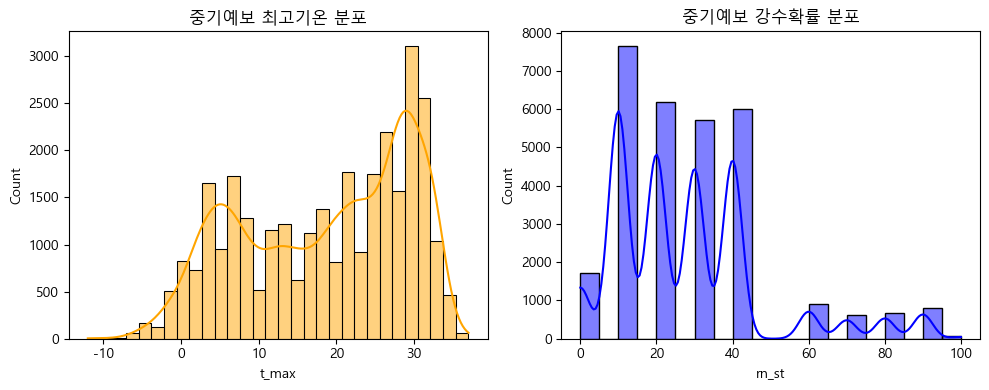

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 최고/최저기온 및 강수확률 분포 확인
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(
    df_forecast_clean['t_max'], bins=30, kde=True, color='orange'
)
plt.title('중기예보 최고기온 분포')

plt.subplot(1, 2, 2)
sns.histplot(
    df_forecast_clean['rn_st'], bins=20, kde=True, color='blue'
)
plt.title('중기예보 강수확률 분포')

plt.tight_layout()
plt.show()

# w4 특보데이터 로드

In [28]:
# 1. 통합된 기상특보 데이터 로드 (경로 형식 일치)
df_warning = pd.read_csv("../data/raw/kma_warning/kma_warning_all.csv")

# 2. 기본 정보 및 상단 5행 확인
print(f"전체 특보 데이터 행 수: {len(df_warning):,}, 컬럼 수: {df_warning.shape[1]}")
display(df_warning.head())
display(df_warning.info())

전체 특보 데이터 행 수: 1,378, 컬럼 수: 40


,region,reg_id,wrn,lvl,tm_fc,tm_ef,tm_ed,cmd,wrn_name,lvl_name,cmd_name,TM_FC,TM_EF,TM_IN,STN,REG_ID,WRN,LVL,CMD,GRD,CNT,RPT,T01,T02,T03,T04,T05,T06,T07,T08,T09,T10,T11,T12,T13,T14,T15,T16,T17,T18
0,서울동남권,L1100100,D,2,2023-01-03 11:00:00,2023-01-03 11:00:00,NaN,1,건조,주의보,발표,202301031100,202301031100,202301031007,109,L1100100,D,2,1,0,4,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,서울동남권,L1100100,D,2,2023-01-06 10:00:00,2023-01-06 10:00:00,NaN,3,건조,주의보,해제,202301061000,202301061000,202301060834,109,L1100100,D,2,3,0,4,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,서울동남권,L1100100,C,2,2023-01-15 11:00:00,2023-01-15 18:00:00,NaN,1,한파,주의보,발표,202301151100,202301151800,202301151044,109,L1100100,C,2,1,0,4,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,서울동남권,L1100100,C,2,2023-01-16 11:00:00,2023-01-16 11:00:00,NaN,3,한파,주의보,해제,202301161100,202301161100,202301160952,109,L1100100,C,2,3,0,4,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,서울동남권,L1100100,C,3,2023-01-23 10:00:00,2023-01-23 21:00:00,NaN,1,한파,경보,발표,202301231000,202301232100,202301230925,109,L1100100,C,3,1,0,4,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1378 entries, 0 to 1377
Data columns (total 40 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   region    1378 non-null   object 
 1   reg_id    1378 non-null   object 
 2   wrn       1378 non-null   object 
 3   lvl       1378 non-null   int64  
 4   tm_fc     1378 non-null   object 
 5   tm_ef     1378 non-null   object 
 6   tm_ed     0 non-null      float64
 7   cmd       1378 non-null   int64  
 8   wrn_name  1378 non-null   object 
 9   lvl_name  1378 non-null   object 
 10  cmd_name  1378 non-null   object 
 11  TM_FC     1378 non-null   int64  
 12  TM_EF     1378 non-null   int64  
 13  TM_IN     1378 non-null   int64  
 14  STN       1378 non-null   int64  
 15  REG_ID    1378 non-null   object 
 16  WRN       1378 non-null   object 
 17  LVL       1378 non-null   int64  
 18  CMD       1378 non-null   int64  
 19  GRD       1378 non-null   int64  
 20  CNT       1378 non-null   int6

None

In [29]:
# 1. 수치형 데이터 기초통계 (있는 경우)
print("--- [수치형 데이터 기초통계] ---")
display(df_warning.describe())

# 2. 범주형 데이터 분포 확인 (특보 종류, 명령, 지역 등)
print("\n--- [범주형 데이터 분포] ---")
for col in ['region', 'wrn_name', 'lvl_name', 'cmd_name']:
    if col in df_warning.columns:
        print(f"\n[{col} 카운트]")
        print(df_warning[col].value_counts(dropna=False))

# 3. 컬럼별 결측치 확인
print("\n--- [컬럼별 결측치 개수] ---")
missing_warning = df_warning.isnull().sum()
print(missing_warning[missing_warning > 0])

--- [수치형 데이터 기초통계] ---


,lvl,tm_ed,cmd,TM_FC,TM_EF,TM_IN,STN,LVL,CMD,GRD,CNT,RPT,T01,T02,T03,T04,T05,T06,T07,T08,T09,T10,T11,T12,T13,T14,T15,T16,T17,T18
count,1378.00,0.00,1378.00,1378.00,1378.00,1378.00,1378.00,1378.00,1378.00,1378.00,1378.00,1378.00,0.00,0.00,23.00,23.00,57.00,57.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
mean,1.91,NaN,2.26,202449529860.34,202449530951.89,202449529687.60,108.99,1.91,2.26,0.00,4.00,101.00,NaN,NaN,13.78,20.17,16.91,20.65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.53,NaN,1.54,107249772.64,107249784.84,107249780.44,0.09,0.53,1.54,0.00,0.00,0.00,NaN,NaN,5.20,2.57,7.05,2.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.00,NaN,1.00,202301031100.00,202301031100.00,202301031007.00,108.00,1.00,1.00,0.00,4.00,101.00,NaN,NaN,1.00,13.00,7.00,14.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2.00,NaN,1.00,202312240940.00,202312241129.50,202312240925.50,109.00,2.00,1.00,0.00,4.00,101.00,NaN,NaN,9.00,19.50,11.00,17.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2.00,NaN,1.00,202501081000.00,202501082100.00,202501080900.00,109.00,2.00,1.00,0.00,4.00,101.00,NaN,NaN,15.00,20.00,18.00,22.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2.00,NaN,3.00,202508308950.00,202508309100.00,202508308890.50,109.00,2.00,3.00,0.00,4.00,101.00,NaN,NaN,18.00,22.00,22.00,23.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,3.00,NaN,6.00,202607291000.00,202607291100.00,202607290950.00,109.00,3.00,6.00,0.00,4.00,101.00,NaN,NaN,21.00,22.00,29.00,23.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- [범주형 데이터 분포] ---

[region 카운트]
region
서울동북권    370
서울서남권    350
서울서북권    334
서울동남권    324
Name: count, dtype: int64

[wrn_name 카운트]
wrn_name
호우     459
대설     216
폭염     216
건조     174
강풍     146
한파     143
태풍      12
열대야     12
Name: count, dtype: int64

[lvl_name 카운트]
lvl_name
주의보    979
예비     264
경보     135
Name: count, dtype: int64

[cmd_name 카운트]
cmd_name
발표    710
해제    536
변경    132
Name: count, dtype: int64

--- [컬럼별 결측치 개수] ---
tm_ed    1378
T01      1378
T02      1378
T03      1355
T04      1355
T05      1321
T06      1321
T07      1378
T08      1378
T09      1378
T10      1378
T11      1378
T12      1378
T13      1378
T14      1378
T15      1378
T16      1378
T17      1378
T18      1378
dtype: int64


In [30]:
# 1. 시계열 관련 컬럼들을 datetime 형식으로 변환
datetime_cols_w4 = ['tm_fc', 'tm_ef', 'tm_ed']

for col in datetime_cols_w4:
    if col in df_warning.columns:
        df_warning[col] = pd.to_datetime(df_warning[col], errors='coerce')

# 2. 불필요한 비고란 컬럼(T01~T18) 제거하여 데이터셋 경량화하기
t_cols = [f"T{i:02d}" for i in range(1, 19)]
df_warning = df_warning.drop(columns=[c for c in t_cols if c in df_warning.columns], errors='ignore')

# 3. 변환 후 타입 및 최종 구조 확인
print("--- [W4 특보 데이터 시계열 타입 확인] ---")
print(df_warning[[c for c in datetime_cols_w4 if c in df_warning.columns]].dtypes)
print(f"\n✨ 정리 완료! 최종 컬럼 수: {df_warning.shape[1]}개, 전체 행 수: {len(df_warning):,}행")

--- [W4 특보 데이터 시계열 타입 확인] ---
tm_fc    datetime64[ns]
tm_ef    datetime64[ns]
tm_ed    datetime64[ns]
dtype: object

✨ 정리 완료! 최종 컬럼 수: 22개, 전체 행 수: 1,378행


In [31]:
print("\n--- [2. 특보 데이터(df_warning) 결측치 및 NaT 점검] ---")
warning_na = df_warning[['tm_fc', 'tm_ef', 'wrn_name', 'cmd_name']].isnull().sum()
print(warning_na)


--- [2. 특보 데이터(df_warning) 결측치 및 NaT 점검] ---
tm_fc       0
tm_ef       0
wrn_name    0
cmd_name    0
dtype: int64


datalab_category